## Part 0 – Load Recorded Audio

We start from the recorded WAV file. No downsampling is allowed because frequency accuracy matters for filter design.

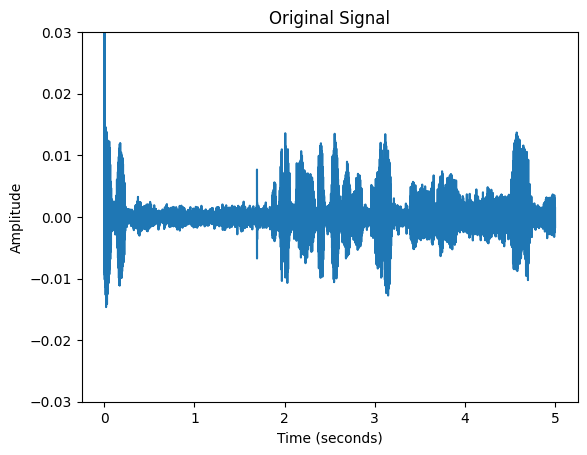

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

audioSignal, samplingRate = sf.read('audio/capture.wav')

# Remove DC offset
audioSignal = audioSignal - np.mean(audioSignal)

samplesAmount = len(audioSignal)
timeAxisSeconds = np.arange(samplesAmount) / samplingRate

plt.plot(timeAxisSeconds, audioSignal)
plt.ylim(-0.03, 0.03)
plt.title("Original Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


## 1: Perform frequency analysis on data.

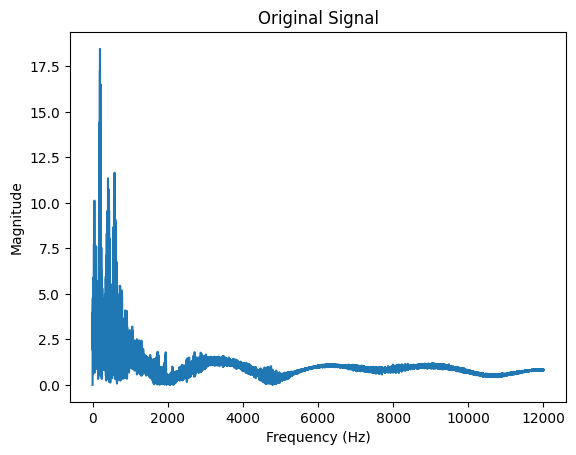

In [38]:
frequencyDomainSignal = np.fft.fft(audioSignal)
magnitudeSpectrum = np.abs(frequencyDomainSignal)

frequencyAxisHertz = np.fft.fftfreq(samplesAmount, d=1/samplingRate)

plt.plot(frequencyAxisHertz[:samplesAmount//2], magnitudeSpectrum[:samplesAmount//2])
plt.title("Original Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()


## 2: Recognize which frequencies are present.

In [39]:
# Identify the top dominant frequencies (magnitude peaks)
topFrequencyIndices = np.argsort(magnitudeSpectrum[:samplesAmount//2])[-10:]
topFrequenciesHertz = frequencyAxisHertz[topFrequencyIndices]
topFrequenciesMagnitudes = magnitudeSpectrum[topFrequencyIndices]

print("Dominant frequencies (Hz):")
print(np.sort(topFrequenciesHertz))


Dominant frequencies (Hz):
[184.6 194.8 195.4 197.  197.4 197.6 204.  214.8 215.2 215.6]


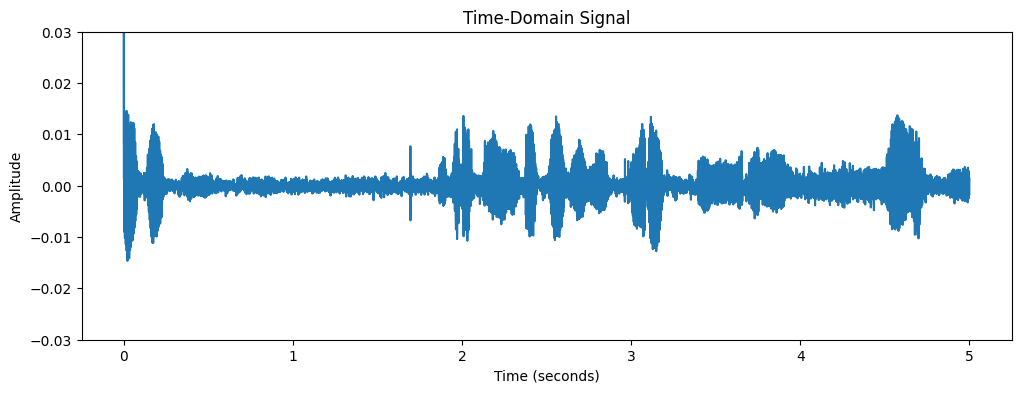

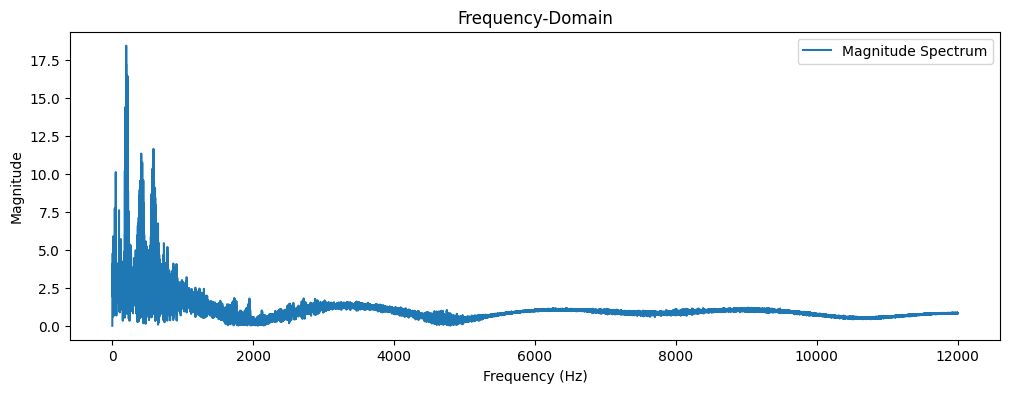

In [40]:
#Plot time-domain signal with markers for peak positions (optional reference points)
plt.figure(figsize=(12,4))
plt.plot(timeAxisSeconds, audioSignal, label="Time-Domain Signal")
plt.ylim(-0.03, 0.03)
plt.title("Time-Domain Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

#Plot frequency-domain spectrum with top peaks highlighted
plt.figure(figsize=(12,4))
plt.plot(frequencyAxisHertz[:samplesAmount//2], magnitudeSpectrum[:samplesAmount//2], label="Magnitude Spectrum")
plt.title("Frequency-Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.show()

## 3: Label signal/noise in spectrum and use this to justify the need for specific filter.

- **Signal of interest:** 50–350 Hz (speech)  
- **Noise:**  
  - Low-frequency frequencies (<50 Hz)  
  - High-frequency frequencies (>350 Hz)

## 4: Design a FIR filter to remove noise. 

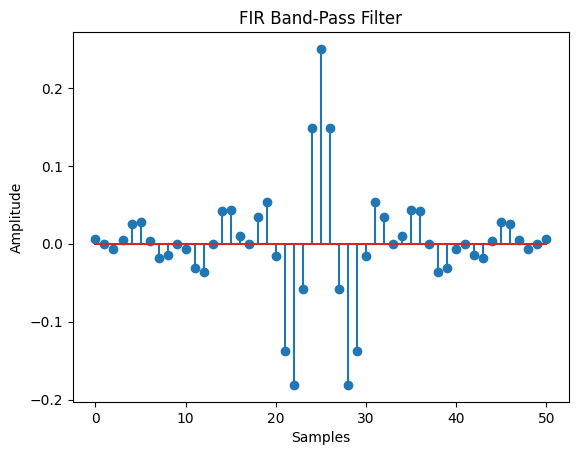

In [ ]:
minFrequency = 50
maxFrequency = 350

def convertHertzToRadiansPerSample(frequencyHertz, samplingRateHertz):
    return 2 * np.pi * frequencyHertz / samplingRateHertz

def createLowPassKernel(cutoffRadiansPerSample, filterHalfLength):
    sampleIndexValues = np.arange(-filterHalfLength, filterHalfLength + 1)
    return cutoffRadiansPerSample / np.pi * np.sinc(cutoffRadiansPerSample / np.pi * sampleIndexValues)

def createBandPassKernel(lowCutoffHertz, highCutoffHertz, samplingRateHertz, filterHalfLength):
    lowCutoffRadians = convertHertzToRadiansPerSample(lowCutoffHertz, samplingRateHertz)
    highCutoffRadians = convertHertzToRadiansPerSample(highCutoffHertz, samplingRateHertz)
    
    lowPassHighKernel = createLowPassKernel(highCutoffRadians, filterHalfLength)
    lowPassLowKernel = createLowPassKernel(lowCutoffRadians, filterHalfLength)
    
    return lowPassHighKernel - lowPassLowKernel

filterHalfLength = 25

bandPassKernel = createBandPassKernel(minFrequency, maxFrequency, samplingRate, filterHalfLength)

plt.stem(bandPassKernel)
plt.title("FIR Band-Pass Filter")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


## 5: Explain how the FIR filter was designed.

1. Convert cutoff frequencies from Hz to radians
2. Build two ideal low-pass sinc filters  
3. Subtract them to create a band-pass filter  
4. Find correct filter length

## 6: Validated that the filter does what it was designed for.

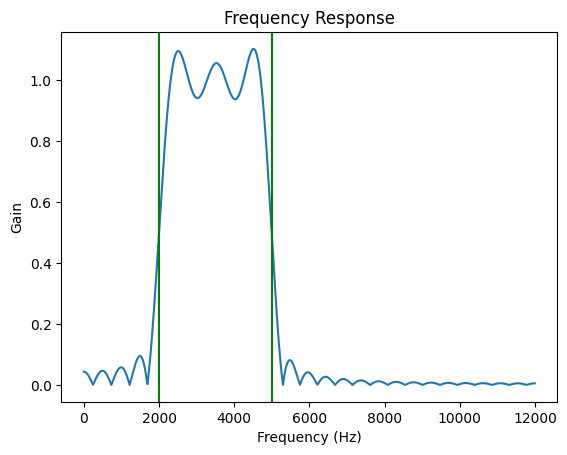

In [42]:
filterFrequencyResponse = np.fft.fft(bandPassKernel, 4096)
filterMagnitudeResponse = np.abs(filterFrequencyResponse)
filterFrequencyAxis = np.fft.fftfreq(4096, d=1/samplingRate)

plt.plot(filterFrequencyAxis[:2048], filterMagnitudeResponse[:2048])
plt.title("Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain")
plt.axvline(minFrequency, color='green')
plt.axvline(maxFrequency, color='green')
plt.show()


## 7: Applied the FIR filter and show the results of the filtering.

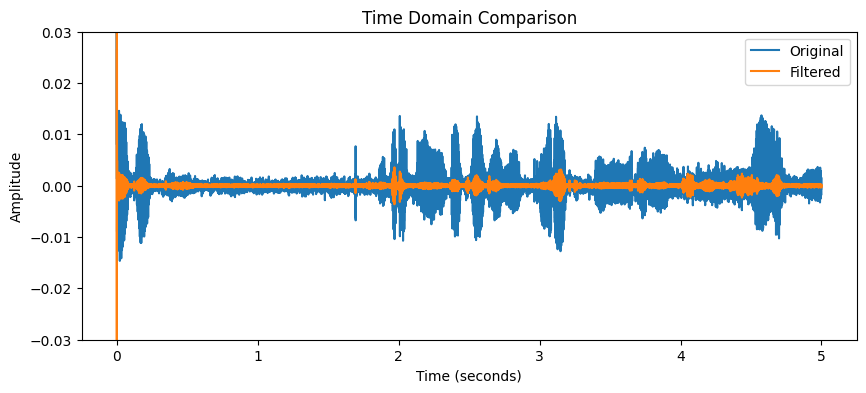

In [43]:
filteredSignal = np.convolve(audioSignal, bandPassKernel, mode='same')

plt.figure(figsize=(10,4))
plt.plot(timeAxisSeconds, audioSignal, label="Original")
plt.plot(timeAxisSeconds, filteredSignal, label="Filtered")
plt.legend()
plt.ylim(-0.03, 0.03)
plt.title("Time Domain Comparison")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

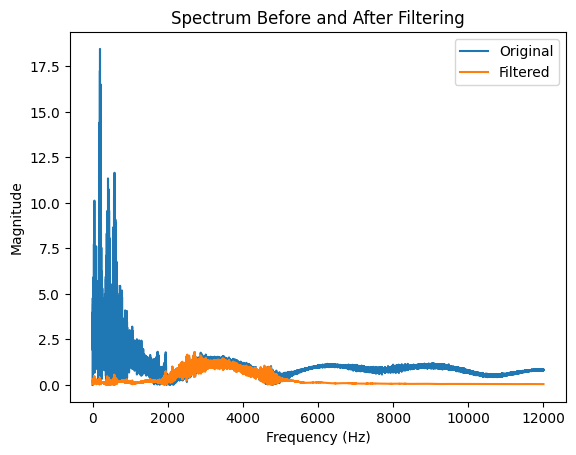

In [44]:
filteredFrequencyDomainSignal = np.fft.fft(filteredSignal)
filteredMagnitudeSpectrum = np.abs(filteredFrequencyDomainSignal)

plt.plot(frequencyAxisHertz[:samplesAmount//2], magnitudeSpectrum[:samplesAmount//2], label="Original")
plt.plot(frequencyAxisHertz[:samplesAmount//2], filteredMagnitudeSpectrum[:samplesAmount//2], label="Filtered")
plt.legend()
plt.title("Spectrum Before and After Filtering")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()


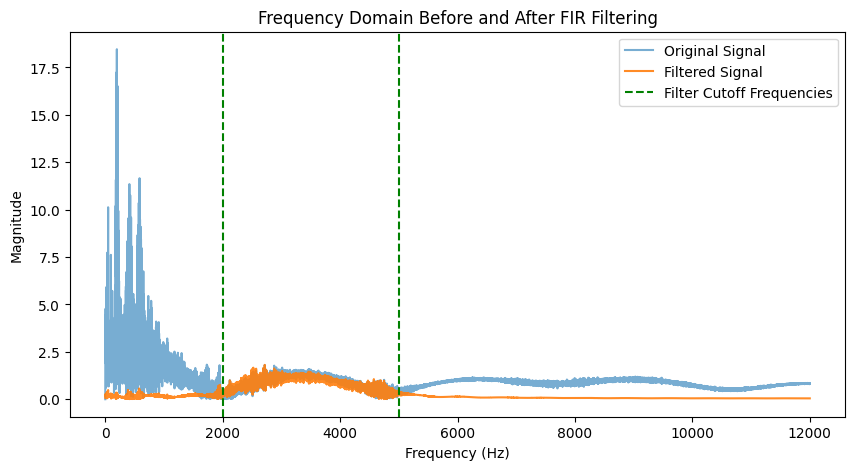

In [45]:
#Compute frequency spectrum
filteredSignalFrequencyDomain = np.fft.fft(filteredSignal)
filteredSignalMagnitudeSpectrum = np.abs(filteredSignalFrequencyDomain)

plt.figure(figsize=(10,5))
plt.plot(frequencyAxisHertz[:samplesAmount//2], magnitudeSpectrum[:samplesAmount//2], label="Original Signal", alpha=0.6)
plt.plot(frequencyAxisHertz[:samplesAmount//2], filteredSignalMagnitudeSpectrum[:samplesAmount//2], label="Filtered Signal", alpha=0.9)

plt.axvline(minFrequency, color='green', linestyle='--', label="Filter Cutoff Frequencies")
plt.axvline(maxFrequency, color='green', linestyle='--')

plt.title("Frequency Domain Before and After FIR Filtering")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.show()
